# Deterministic MPC with PV and BESS in the Existing CasADi Framework

This notebook uses the existing `MPC_solver` together with the new `BuildingBESS` wrapper.

Modeled electrical paths in this first version:
- PV -> HP
- PV -> BESS
- BESS -> HP
- Grid -> HP

Not included here:
- no grid charging of the BESS
- no export
- no thermal storage
- no uncertainty

In [1]:
from pathlib import Path
import sys

import casadi as cas
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import data.buildings as building_data
import src.disturbances as disturbances
from src.controller.mpc.casadi_framework import MPC_solver
from src.models.model_bess import BESS, BuildingBESS
from src.models.model_buildings import Building
from src.models.model_hvac import Heatpump_AW

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
building_name = "sfh_2016_now_0_soc"
method = "2R2C"
mdot_hp = 0.25
h = 3600
nk = 24
year = 2015
start_day = 180
pv_peak_kw = 5.0
grid_column = "EEX2020"
grid_scale = 0.001 * 100.0  # convert the CSV signal to ct/kWh like the existing code path
bess_capacity_kwh = 6.0
bess_power_kw = 3.0
bess_soc_init = 0.5
eta_ch = 0.95
eta_dis = 0.95

building_params = getattr(building_data, building_name)
base_building = Building(
    params=building_params,
    mdot_hp=mdot_hp,
    method=method,
    T_room_set_lower=20,
)
hp_model = Heatpump_AW(mdot_HP=mdot_hp)

In [3]:
def build_external_inputs(base_building, repo_root, h, year, start_day, nk, pv_peak_kw, grid_column, grid_scale):
    disturbances_df = disturbances.generate_disturbances_all(
        base_building,
        year=year,
        timestep=h,
        GRID_ON=False,
        repo_filepath=str(repo_root),
    )

    pos = base_building.params["position"]
    weather = disturbances.load_weather(
        latitude=pos["lat"],
        longitude=pos["long"],
        altitude=pos["altitude"],
        year=year,
        repo_filepath=str(repo_root),
    ).iloc[:8760]

    pv_hourly = pv_peak_kw * weather["ghi"].clip(lower=0.0) / 1000.0
    pv_resampled = pv_hourly.resample(f"{h}s").ffill().rename("pv_kw")

    grid_raw = pd.read_csv(repo_root / "data" / "grid" / "grid_signals.csv")[grid_column].iloc[: len(weather)]
    grid_hourly = pd.Series(grid_raw.to_numpy(dtype=float) * grid_scale, index=weather.index, name="grid")
    grid_resampled = grid_hourly.resample(f"{h}s").ffill()

    data = disturbances_df[["T_amb", "Qdot_gains", "T_room_set_lower"]].copy()
    data["pv_kw"] = pv_resampled.reindex(data.index).fillna(0.0)
    data["grid"] = grid_resampled.reindex(data.index).ffill().fillna(0.0)

    start_idx = start_day * int(24 * 3600 / h)
    stop_idx = start_idx + nk + 1
    return data.iloc[start_idx:stop_idx].copy()


def decode_solution(mpc, res, model, hp_model, parameter_frame):
    d = mpc.dim["d"]
    nx = mpc.dim["nx"]
    nu = mpc.dim["nu"]
    ns = mpc.dim["ns"]
    step_width = (d + 1) * (nx + ns) + nu
    vector = np.asarray(res["x"]).reshape(-1)

    states = []
    controls = []
    for k in range(mpc.nk):
        offset = k * step_width
        states.append(vector[offset : offset + nx])
        control_offset = offset + (d + 1) * (nx + ns)
        controls.append(vector[control_offset : control_offset + nu])

    terminal_offset = mpc.nk * step_width
    states.append(vector[terminal_offset : terminal_offset + nx])

    states_df = pd.DataFrame(np.vstack(states), columns=model.state_keys)
    controls_df = pd.DataFrame(np.vstack(controls), columns=model.control_keys)
    parameters = parameter_frame.iloc[: mpc.nk].reset_index(drop=True)

    t_return = states_df["T_hp_ret"].iloc[: mpc.nk].to_numpy(dtype=float)
    t_supply = controls_df["T_hp_sup"].to_numpy(dtype=float)
    t_amb = parameters["T_amb"].to_numpy(dtype=float)
    cop = hp_model.COP(t_supply, t_amb)
    qth_kw = hp_model.mdot_HP * hp_model.c_water * (t_supply - t_return) / 1000.0
    hp_el_power_kw = qth_kw / cop
    grid_import_kw = hp_el_power_kw - controls_df["P_pv_hp_kw"].to_numpy(dtype=float) - controls_df["P_bess_hp_kw"].to_numpy(dtype=float)

    horizon = pd.DataFrame({
        "time_h": np.arange(mpc.nk + 1) * h / 3600.0,
        **{col: states_df[col].to_numpy(dtype=float) for col in states_df.columns},
    })
    control_horizon = pd.DataFrame({
        "time_h": np.arange(mpc.nk) * h / 3600.0,
        **{col: controls_df[col].to_numpy(dtype=float) for col in controls_df.columns},
        "T_amb": parameters["T_amb"].to_numpy(dtype=float),
        "grid": parameters["grid"].to_numpy(dtype=float),
        "pv_kw": parameters["pv_kw"].to_numpy(dtype=float),
        "hp_el_power_kw": hp_el_power_kw,
        "grid_import_kw": grid_import_kw,
    })

    summary = {
        "objective": float(res["f"]),
        "grid_import_kwh": float(np.sum(grid_import_kw) * h / 3600.0),
        "pv_to_hp_kwh": float(np.sum(control_horizon["P_pv_hp_kw"]) * h / 3600.0),
        "pv_to_bess_kwh": float(np.sum(control_horizon["P_pv_bess_kw"]) * h / 3600.0),
        "bess_to_hp_kwh": float(np.sum(control_horizon["P_bess_hp_kw"]) * h / 3600.0),
    }
    return horizon, control_horizon, summary


def solve_case(case_name, bess_capacity_kwh, pv_override=None):
    base = Building(
        params=building_params,
        mdot_hp=mdot_hp,
        method=method,
        T_room_set_lower=20,
    )
    bess = BESS(
        capacity_kwh=bess_capacity_kwh,
        soc_init=bess_soc_init,
        p_ch_max_kw=bess_power_kw,
        p_dis_max_kw=bess_power_kw,
        eta_ch=eta_ch,
        eta_dis=eta_dis,
    )
    model = BuildingBESS(base, bess)
    parameter_frame = build_external_inputs(
        base,
        repo_root,
        h,
        year,
        start_day,
        nk,
        pv_peak_kw,
        grid_column,
        grid_scale,
    )
    if pv_override is not None:
        parameter_frame["pv_kw"] = pv_override

    solver = MPC_solver(
        resultdir="results_mpc",
        resultfile=f"pv_bess_framework_{case_name}",
        hp_model=hp_model,
        building_model=model,
        nx=len(model.state_keys),
        nu=len(model.control_keys),
        npar=len(model.parameter_keys),
        ns=1,
        nc=5,
        h=h,
        nk=nk,
        ws=0.1,
    )
    x0 = np.array([20.0] * len(base.state_keys) + [bess.initial_energy_kwh], dtype=float)
    solver.update_NLP(x0)
    P = parameter_frame.loc[:, model.parameter_keys].to_numpy(dtype=float)
    _, _, res = solver.solve_NLP(P, return_res=True)
    state_traj, control_traj, summary = decode_solution(solver, res, model, hp_model, parameter_frame)
    return {
        "case": case_name,
        "parameters": parameter_frame,
        "state": state_traj,
        "control": control_traj,
        "summary": summary,
    }

In [4]:
case_bess = solve_case("bess_active", bess_capacity_kwh=bess_capacity_kwh)
case_no_bess = solve_case("bess_disabled", bess_capacity_kwh=0.0)

summary = pd.DataFrame([
    {"case": case_bess["case"], **case_bess["summary"]},
    {"case": case_no_bess["case"], **case_no_bess["summary"]},
])
summary

CasADi - 2026-04-09 12:46:05 WARNING("NLP is overconstrained: There are 532 equality constraints but only 484 variables.") [.../casadi/core/nlpsol.cpp:658]


,case,objective,grid_import_kwh,pv_to_hp_kwh,pv_to_bess_kwh,bess_to_hp_kwh
0,bess_active,49.262367,1.326224,0.242631,1.747272e+00,9.461353e-01
1,bess_disabled,50.768140,1.239791,0.443597,-6.155774e-08,-3.904703e-08


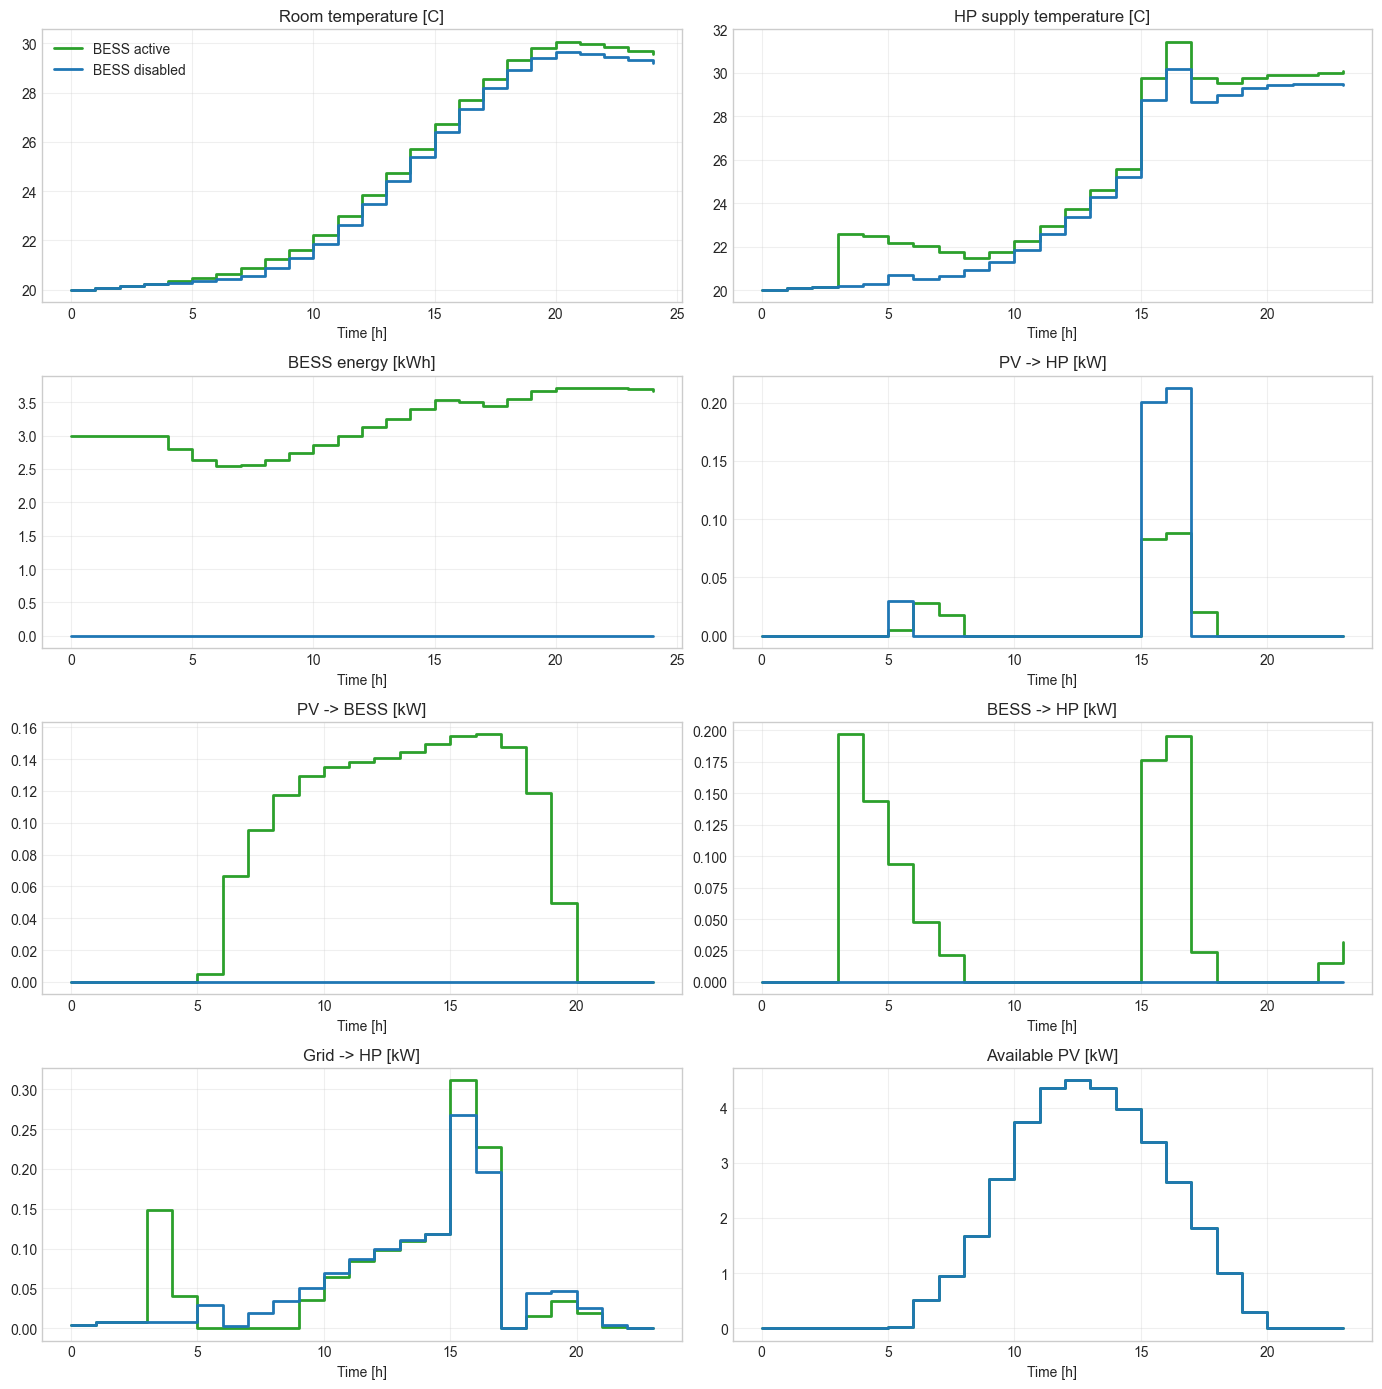

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=False)
axes = axes.ravel()

state_specs = [
    ("T_room", "Room temperature [C]", "state"),
    ("T_hp_sup", "HP supply temperature [C]", "control"),
    ("E_bess_kWh", "BESS energy [kWh]", "state"),
    ("P_pv_hp_kw", "PV -> HP [kW]", "control"),
    ("P_pv_bess_kw", "PV -> BESS [kW]", "control"),
    ("P_bess_hp_kw", "BESS -> HP [kW]", "control"),
    ("grid_import_kw", "Grid -> HP [kW]", "control"),
    ("pv_kw", "Available PV [kW]", "control"),
]

for ax, (column, title, source) in zip(axes, state_specs):
    for case, label, color in [
        (case_bess, "BESS active", "tab:green"),
        (case_no_bess, "BESS disabled", "tab:blue"),
    ]:
        frame = case[source]
        ax.step(frame["time_h"], frame[column], where="post", linewidth=2.0, label=label, color=color)
    ax.set_title(title)
    ax.set_xlabel("Time [h]")
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="best")
fig.tight_layout()
plt.show()

The zero-capacity case uses the same extended model, but fixes the BESS state and the BESS-specific flows to zero through bounds.
This keeps the extended CasADi path usable even when the storage is disabled.